# WDL/LWDL Timing Results

This notebook loads the newest completed Mark 2 timing run by default, summarizes the trial table, and plots W2 reconstruction error, runtime, iteration counts, and termination status.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

In [2]:
def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "experiments" / "timed_comparison").exists() and (path / "SAE.py").exists():
            return path
        if (path / "wdl_repo" / "experiments" / "timed_comparison").exists():
            return path / "wdl_repo"
    raise FileNotFoundError("Could not find WDL repo root")

REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "experiments" / "results"

# Set this manually to inspect a specific run.
RUN_DIR = None

if RUN_DIR is None:
    completed_runs = []
    for path in RESULTS_DIR.glob("timing_suite_mark2_*"):
        summary_path = path / "summary.json"
        table_path = path / "timing_table_mark2.csv"
        if not summary_path.exists() or not table_path.exists():
            continue
        summary = json.loads(summary_path.read_text())
        if summary.get("partial") is False:
            completed_runs.append(path)
    if not completed_runs:
        raise FileNotFoundError(f"No completed timing_suite_mark2_* runs found under {RESULTS_DIR}")
    RUN_DIR = max(completed_runs, key=lambda p: p.stat().st_mtime)

RUN_DIR = Path(RUN_DIR)
summary = json.loads((RUN_DIR / "summary.json").read_text())
manifest = json.loads((RUN_DIR / "manifest.json").read_text())
df = pd.read_csv(RUN_DIR / "timing_table_mark2.csv")

print(f"Run: {RUN_DIR}")
print(f"Rows: {summary.get('num_rows')} | partial: {summary.get('partial')}")
print(f"Duration target: {manifest.get('duration_seconds')} seconds")
display(df)

Run: REPO_ROOT/experiments/results/timing_suite_mark2_20260727_193741
Rows: 13 | partial: False
Duration target: 1000.0 seconds


,experiment,sample_size,method,variant,epsilon,gamma,sinkhorn_iters,embedding_seconds,train_seconds,clock_time_seconds,...,iterations_completed,termination_reason,mean_w2_squared,embedded_recon_loss,eval_status,eval_warning,numerical_error,model_state_path,history_path,artifact
0,pavia1d,1000,transport_map,JumpReLU_monotone,NaN,NaN,NaN,0.504459,1001.24,1001.74,...,268584,max_elapsed_seconds,9.17707e-05,7.07175e-05,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n1000/transport_map_history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/_cache/pavia1d/embeddings/hsi_1d_dataa478eb738ecf_ep...
1,pavia1d,1000,heitz,wasserstein_dictionary_learning,NaN,0.5,5,0,282.367,282.367,...,7,nonfinite_loss,0.00568849,NaN,ok,NaN,True,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n1000/heitz_gamma0p5_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n1000/heitz_gamma0p5_sink5
2,pavia1d,1000,heitz,wasserstein_dictionary_learning,NaN,2,5,0,272.37,272.37,...,7,nonfinite_loss,0.00602771,NaN,ok,NaN,True,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n1000/heitz_gamma2_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n1000/heitz_gamma2_sink5
3,pavia1d,100,transport_map,JumpReLU_monotone,NaN,NaN,NaN,0.0632714,1000.02,1000.08,...,237556,max_elapsed_seconds,5.60572e-05,3.60761e-05,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/transport_map_history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/_cache/pavia1d/embeddings/hsi_1d_data5c6f5fe492d0_ep...
4,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,0.5,5,0,1009.57,1009.57,...,117,max_elapsed_seconds,0.00456313,NaN,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma0p5_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma0p5_sink5
5,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,2,5,0,1001.69,1001.69,...,85,max_elapsed_seconds,0.00478546,NaN,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma2_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma2_sink5
6,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,10,5,0,1001.6,1001.6,...,151,max_elapsed_seconds,0.00499874,NaN,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma10_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/pavia1d/n100/heitz_gamma10_sink5
7,mnist,1000,ebcm,entropic_displacement,0.025,NaN,NaN,31.4868,1000.19,1031.68,...,52012,max_elapsed_seconds,0.00269696,0.000323311,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/mnist/n1000/ebcm_eps0p025_history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/_cache/mnist/embeddings/digits0-1-2-3-4-5-6-7-8-9_n1...
8,mnist,1000,heitz,wasserstein_dictionary_learning,NaN,0.5,5,0,1006.53,1006.53,...,10,max_elapsed_seconds,0.0128444,NaN,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/mnist/n1000/heitz_gamma0p5_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/mnist/n1000/heitz_gamma0p5_sink5
9,mnist,1000,heitz,wasserstein_dictionary_learning,NaN,2,5,0,1029.66,1029.66,...,11,max_elapsed_seconds,0.013064,NaN,ok,NaN,False,NaN,experiments/results/timing_suite_mark2_20260727_193741/mnist/n1000/heitz_gamma2_sink5/history.jsonl,experiments/results/timing_suite_mark2_20260727_193741/mnist/n1000/heitz_gamma2_sink5


In [3]:
def trial_label(row):
    if row["method"] == "heitz":
        return f"Heitz gamma={row['gamma']:g}"
    if row["method"] == "transport_map":
        return "LWDL transport"
    if row["method"] == "ebcm":
        return f"LWDL EBCM eps={row['epsilon']:g}"
    return str(row["method"])

plot_df = df.copy()
plot_df["trial"] = plot_df.apply(trial_label, axis=1)
plot_df["dataset"] = plot_df["experiment"].map({"pavia1d": "Pavia 1D", "mnist": "MNIST 2D"}).fillna(plot_df["experiment"])
plot_df["status"] = np.where(plot_df["numerical_error"].astype(bool), "numerical error", plot_df["termination_reason"].fillna("unknown"))

summary_cols = [
    "dataset", "sample_size", "trial", "mean_w2_squared", "clock_time_seconds",
    "iterations_completed", "termination_reason", "numerical_error", "eval_status"
]
display(plot_df[summary_cols].sort_values(["dataset", "sample_size", "trial"]))

,dataset,sample_size,trial,mean_w2_squared,clock_time_seconds,iterations_completed,termination_reason,numerical_error,eval_status
11,MNIST 2D,100,Heitz gamma=0.5,0.0121877,1015.42,101,max_elapsed_seconds,False,ok
12,MNIST 2D,100,Heitz gamma=2,0.0100592,1006.2,101,max_elapsed_seconds,False,ok
10,MNIST 2D,100,LWDL EBCM eps=0.025,0.00258071,1003.54,52360,max_elapsed_seconds,False,ok
8,MNIST 2D,1000,Heitz gamma=0.5,0.0128444,1006.53,10,max_elapsed_seconds,False,ok
9,MNIST 2D,1000,Heitz gamma=2,0.013064,1029.66,11,max_elapsed_seconds,False,ok
7,MNIST 2D,1000,LWDL EBCM eps=0.025,0.00269696,1031.68,52012,max_elapsed_seconds,False,ok
4,Pavia 1D,100,Heitz gamma=0.5,0.00456313,1009.57,117,max_elapsed_seconds,False,ok
6,Pavia 1D,100,Heitz gamma=10,0.00499874,1001.6,151,max_elapsed_seconds,False,ok
5,Pavia 1D,100,Heitz gamma=2,0.00478546,1001.69,85,max_elapsed_seconds,False,ok
3,Pavia 1D,100,LWDL transport,5.60572e-05,1000.08,237556,max_elapsed_seconds,False,ok


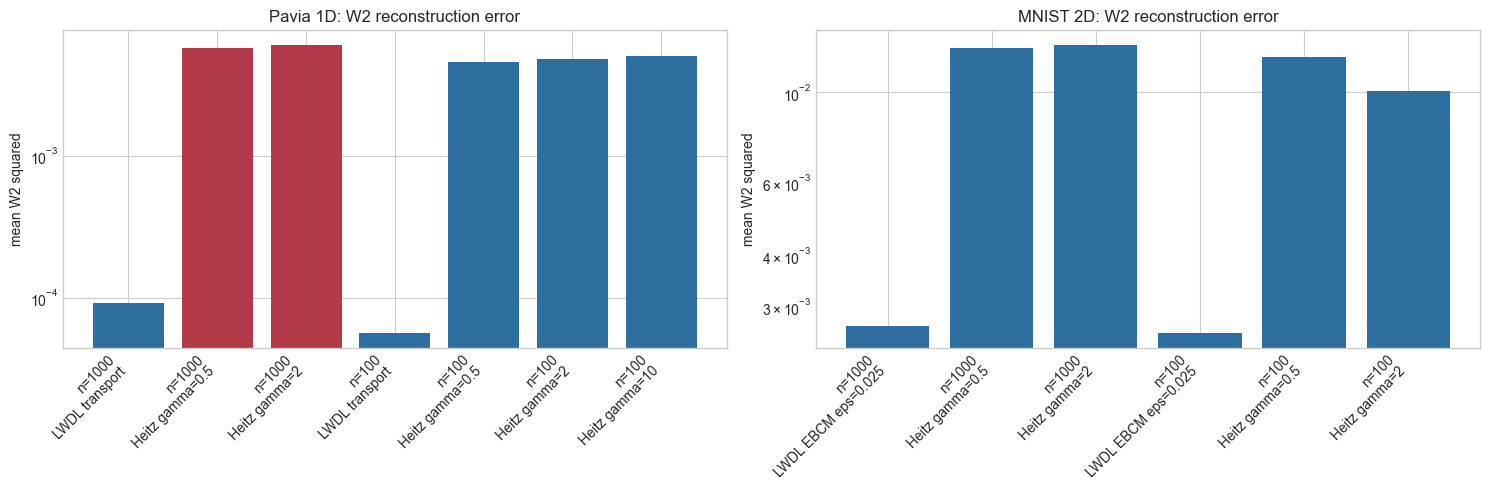

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, (dataset, group) in zip(axes, plot_df.groupby("dataset", sort=False)):
    labels = [f"n={int(r.sample_size)}\n{r.trial}" for r in group.itertuples()]
    colors = ["#b23a48" if bool(r.numerical_error) else "#2f6f9f" for r in group.itertuples()]
    ax.bar(range(len(group)), group["mean_w2_squared"], color=colors)
    ax.set_title(f"{dataset}: W2 reconstruction error")
    ax.set_ylabel("mean W2 squared")
    ax.set_xticks(range(len(group)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yscale("log")

fig.tight_layout()
plt.show()

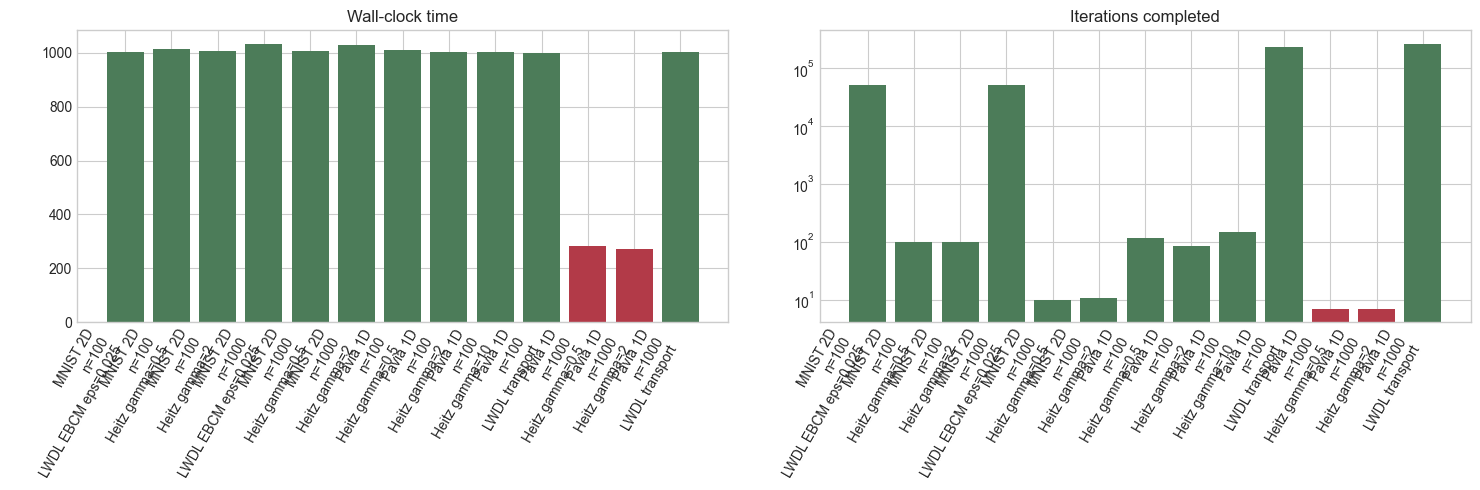

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in [
    (axes[0], "clock_time_seconds", "Wall-clock time"),
    (axes[1], "iterations_completed", "Iterations completed"),
]:
    ordered = plot_df.sort_values(["dataset", "sample_size", "method", "gamma"])
    labels = [f"{r.dataset}\nn={int(r.sample_size)}\n{r.trial}" for r in ordered.itertuples()]
    colors = ["#b23a48" if bool(r.numerical_error) else "#4c7c59" for r in ordered.itertuples()]
    ax.bar(range(len(ordered)), ordered[metric], color=colors)
    ax.set_title(title)
    ax.set_xticks(range(len(ordered)))
    ax.set_xticklabels(labels, rotation=60, ha="right")
    if metric == "iterations_completed":
        ax.set_yscale("log")

fig.tight_layout()
plt.show()

In [6]:
status_table = (
    plot_df.groupby(["dataset", "sample_size", "method", "trial", "termination_reason", "numerical_error"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
)
display(status_table)

,dataset,sample_size,method,trial,termination_reason,numerical_error,count
0,MNIST 2D,100,ebcm,LWDL EBCM eps=0.025,max_elapsed_seconds,False,1
1,MNIST 2D,100,heitz,Heitz gamma=0.5,max_elapsed_seconds,False,1
2,MNIST 2D,100,heitz,Heitz gamma=2,max_elapsed_seconds,False,1
3,MNIST 2D,1000,ebcm,LWDL EBCM eps=0.025,max_elapsed_seconds,False,1
4,MNIST 2D,1000,heitz,Heitz gamma=0.5,max_elapsed_seconds,False,1
5,MNIST 2D,1000,heitz,Heitz gamma=2,max_elapsed_seconds,False,1
6,Pavia 1D,100,heitz,Heitz gamma=0.5,max_elapsed_seconds,False,1
7,Pavia 1D,100,heitz,Heitz gamma=10,max_elapsed_seconds,False,1
8,Pavia 1D,100,heitz,Heitz gamma=2,max_elapsed_seconds,False,1
9,Pavia 1D,100,transport_map,LWDL transport,max_elapsed_seconds,False,1


## Paper-Style Tables

Compact four-column tables, split by dataset. The sample size is included in the method label so the table keeps the same shape as the manuscript example.

In [7]:
def sci_tex(value):
    if pd.isna(value):
        return "--"
    exponent = int(np.floor(np.log10(abs(value)))) if value != 0 else 0
    mantissa = value / (10 ** exponent) if value != 0 else 0
    return rf"${mantissa:.1f}\times 10^{{{exponent}}}$"


def paper_method_label(row):
    n = int(row["sample_size"])
    if row["method"] == "heitz":
        label = rf"WDL ($\gamma={row['gamma']:g}$)"
    elif row["method"] == "transport_map":
        label = "LWDL"
    elif row["method"] == "ebcm":
        label = rf"LWDL-EOT ($\epsilon={row['epsilon']:g}, c=5\times 10^{{-5}}$)"
    else:
        label = str(row["method"])
    return rf"{label}, $n={n}$"


def make_paper_table(source_df, experiment):
    rows = []
    subset = source_df[source_df["experiment"] == experiment].copy()
    subset = subset.sort_values(["sample_size", "method", "gamma"], ascending=[False, True, True])
    for _, row in subset.iterrows():
        epochs_or_iters = row["epochs_completed"] if row["method"] != "heitz" else row["iterations_completed"]
        rows.append({
            "Method": paper_method_label(row),
            r"Mean $W_2^2$": sci_tex(row["mean_w2_squared"]),
            "Epochs": f"${int(epochs_or_iters):d}$" if pd.notna(epochs_or_iters) else "--",
            "Time (s)": f"${row['clock_time_seconds']:.2f}$",
        })
    return pd.DataFrame(rows)


def dataframe_to_booktabs_latex(table_df, caption, label):
    lines = [
        r"\begin{table}",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{lccc}",
        r"\toprule",
        r"Method & Mean $W_2^2$ & Epochs & Time (s)\\",
        r"\midrule",
    ]
    for _, row in table_df.iterrows():
        lines.append("{} & {} & {} & {} \\\\".format(
            row["Method"], row[r"Mean $W_2^2$"], row["Epochs"], row["Time (s)"]
        ))
    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])
    return "\n".join(lines)


pavia_table = make_paper_table(df, "pavia1d")
mnist_table = make_paper_table(df, "mnist")

display(pavia_table)
display(mnist_table)

print(dataframe_to_booktabs_latex(pavia_table, "Pavia 1D timing comparison.", "tab:pavia_timing"))
print()
print(dataframe_to_booktabs_latex(mnist_table, "MNIST timing comparison.", "tab:mnist_timing"))

,Method,Mean $W_2^2$,Epochs,Time (s)
0,"WDL ($\gamma=0.5$), $n=1000$",$5.7\times 10^{-3}$,$7$,$282.37$
1,"WDL ($\gamma=2$), $n=1000$",$6.0\times 10^{-3}$,$7$,$272.37$
2,"LWDL, $n=1000$",$9.2\times 10^{-5}$,$67146$,$1001.74$
3,"WDL ($\gamma=0.5$), $n=100$",$4.6\times 10^{-3}$,$117$,$1009.57$
4,"WDL ($\gamma=2$), $n=100$",$4.8\times 10^{-3}$,$85$,$1001.69$
5,"WDL ($\gamma=10$), $n=100$",$5.0\times 10^{-3}$,$151$,$1001.60$
6,"LWDL, $n=100$",$5.6\times 10^{-5}$,$237556$,$1000.08$


,Method,Mean $W_2^2$,Epochs,Time (s)
0,"LWDL-EOT ($\epsilon=0.025, c=5\times 10^{-5}$), $n=1000$",$2.7\times 10^{-3}$,$13003$,$1031.68$
1,"WDL ($\gamma=0.5$), $n=1000$",$1.3\times 10^{-2}$,$10$,$1006.53$
2,"WDL ($\gamma=2$), $n=1000$",$1.3\times 10^{-2}$,$11$,$1029.66$
3,"LWDL-EOT ($\epsilon=0.025, c=5\times 10^{-5}$), $n=100$",$2.6\times 10^{-3}$,$52360$,$1003.54$
4,"WDL ($\gamma=0.5$), $n=100$",$1.2\times 10^{-2}$,$101$,$1015.42$
5,"WDL ($\gamma=2$), $n=100$",$1.0\times 10^{-2}$,$101$,$1006.20$


\begin{table}
\centering
\caption{Pavia 1D timing comparison.}
\label{tab:pavia_timing}
\begin{tabular}{lccc}
\toprule
Method & Mean $W_2^2$ & Epochs & Time (s)\\
\midrule
WDL ($\gamma=0.5$), $n=1000$ & $5.7\times 10^{-3}$ & $7$ & $282.37$ \\
WDL ($\gamma=2$), $n=1000$ & $6.0\times 10^{-3}$ & $7$ & $272.37$ \\
LWDL, $n=1000$ & $9.2\times 10^{-5}$ & $67146$ & $1001.74$ \\
WDL ($\gamma=0.5$), $n=100$ & $4.6\times 10^{-3}$ & $117$ & $1009.57$ \\
WDL ($\gamma=2$), $n=100$ & $4.8\times 10^{-3}$ & $85$ & $1001.69$ \\
WDL ($\gamma=10$), $n=100$ & $5.0\times 10^{-3}$ & $151$ & $1001.60$ \\
LWDL, $n=100$ & $5.6\times 10^{-5}$ & $237556$ & $1000.08$ \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\centering
\caption{MNIST timing comparison.}
\label{tab:mnist_timing}
\begin{tabular}{lccc}
\toprule
Method & Mean $W_2^2$ & Epochs & Time (s)\\
\midrule
LWDL-EOT ($\epsilon=0.025, c=5\times 10^{-5}$), $n=1000$ & $2.7\times 10^{-3}$ & $13003$ & $1031.68$ \\
WDL ($\gamma=0.5$), $n=1000$ & $1.3\t

In [8]:
for image_name in ["loss_curves_pavia1d.png", "loss_curves_mnist.png"]:
    image_path = RUN_DIR / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))
    else:
        print(f"Missing: {image_path}")

Missing: REPO_ROOT/experiments/results/timing_suite_mark2_20260727_193741/loss_curves_pavia1d.png
Missing: REPO_ROOT/experiments/results/timing_suite_mark2_20260727_193741/loss_curves_mnist.png
